# Inteligência Artificial Aplicada à Esclerose Múltipla: Preditores de Progressão e Estilo de Vida - Capítulo 2

## 1. Criando os dados sintéticos

In [ ]:
import pandas as pd
import numpy as np
# Fazendo os resultados serem os mesmos toda vez que rodar o código
np.random.seed(42)
# Simulando um grupo de 500 pacientes
n_pacientes = 500
# GERANDO O HISTÓRICO DE ESTILO DE VIDA
idade = np.random.randint(20, 65, n_pacientes)
fumante = np.random.choice([0, 1], p=[0.8, 0.2], size=n_pacientes) # 20% são fumantes
vitamina_d = np.random.randint(10, 70, n_pacientes) # Níveis de 10 a 70
estresse = np.random.randint(1, 11, n_pacientes) # Escala de 1 a 10
exercicio = np.random.randint(0, 8, n_pacientes) # Dias por semana (0 a 7)
poluicao = np.random.randint(20, 150, n_pacientes) # Índice de Qualidade do Ar (AQI)
# Outras variáveis
horas_sono = np.random.normal(7, 1.5, n_pacientes).round(1) 
qualidade_sono = np.random.randint(1, 11, n_pacientes) # Nota de 1 (Péssimo) a 10 (Excelente)
outra_autoimune = np.random.choice([0, 1], p=[0.85, 0.15], size=n_pacientes) # 15% têm outra doença autoimune
# CALCULANDO O RISCO DE PIORA
risco = 0.05 
# Fatores que aumentam o risco
risco += fumante * 0.30
risco += outra_autoimune * 0.20                    
risco += (estresse / 10) * 0.15
risco += (poluicao / 150) * 0.10
# Influência do sono
risco += np.where(horas_sono < 6, 0.10, 0)         # Dormir menos de 6h aumenta o risco
risco += ((10 - qualidade_sono) / 10) * 0.15       # Qualidade ruim aumenta o risco
# fatores protetores
risco -= (vitamina_d / 70) * 0.20
risco -= (exercicio / 7) * 0.15
# Garantindo que a probabilidade fique dentro dos limites reais (entre 2% e 95%)
risco = np.clip(risco, 0.02, 0.95)
# Criando o DataFrame
houve_progressao = np.random.binomial(1, risco)
df_estilo = pd.DataFrame({
    'Idade': idade,
    'Fumante_0_1': fumante,
    'Outra_Autoimune_0_1': outra_autoimune,
    'Vitamina_D_ng_mL': vitamina_d,
    'Nivel_Estresse_1_10': estresse,
    'Exercicio_Dias_Semana': exercicio,
    'Poluicao_Ar_AQI': poluicao,
    'Horas_Sono': horas_sono,
    'Qualidade_Sono_1_10': qualidade_sono,
    'Houve_Progressao': houve_progressao
})
# Salvando o DataFrame em um arquivo CSV
nome_arquivo = 'dados_estilo_vida_simulados_v2.csv'
df_estilo.to_csv(nome_arquivo, index=False)
print(f"A tabela foi salva como '{nome_arquivo}'.")
print("\n📊 Primeiras linhas dos pacientes:")
display(df_estilo.head())

A tabela foi salva como 'dados_estilo_vida_simulados_v2.csv'.

📊 Primeiras linhas dos pacientes:


,Idade,Fumante_0_1,Outra_Autoimune_0_1,Vitamina_D_ng_mL,Nivel_Estresse_1_10,Exercicio_Dias_Semana,Poluicao_Ar_AQI,Horas_Sono,Qualidade_Sono_1_10,Houve_Progressao
0,58,0,0,42,2,3,47,6.8,7,0
1,48,0,0,32,8,0,70,8.0,10,0
2,34,0,0,64,3,1,24,7.3,10,0
3,62,0,0,37,10,0,24,5.9,2,1
4,27,0,0,41,3,6,113,6.5,9,0


### Criando o Mapa de Calor

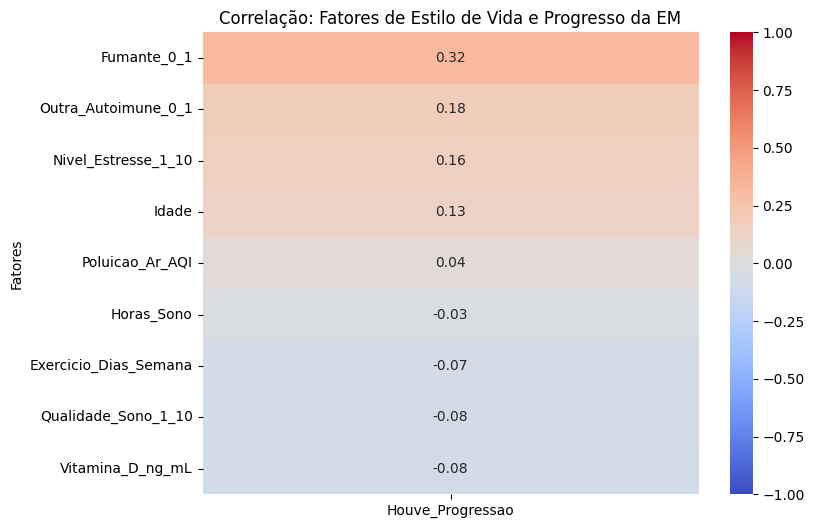

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
# Calculando a correlação
correlacao_estilovida = df_estilo.corr()
# Focando apenas no que causa a piora 
alvo_corr_estilo = correlacao_estilovida[['Houve_Progressao']].sort_values(by='Houve_Progressao', ascending=False)
# Retirando a coluna de progressão
alvo_corr_estilo = alvo_corr_estilo.drop('Houve_Progressao')
# Desenhando o gráfico
plt.figure(figsize=(8, 6))
sns.heatmap(alvo_corr_estilo, vmin=-1, vmax=1, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlação: Fatores de Estilo de Vida e Progresso da EM', fontsize=12)
plt.ylabel('Fatores')
plt.show()

## 2. Criando a Inteligência Artificial para analisar a influência do estilo de vida na progressão da Esclerose múltipla

CAPÍTULO 2 (Estilo de Vida):
              precision    recall  f1-score   support

 Estável (0)       0.88      1.00      0.93        85
  Piorou (1)       1.00      0.20      0.33        15

    accuracy                           0.88       100
   macro avg       0.94      0.60      0.63       100
weighted avg       0.89      0.88      0.84       100



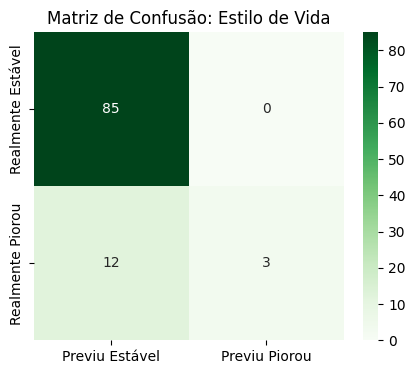

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
# Definindo as variaveis de entrada (X) e a variável alvo (y)
x = df_estilo.drop('Houve_Progressao', axis=1)
y = df_estilo['Houve_Progressao']
# Dividindo os dados em treino e teste
x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size=0.2, random_state=42)
# Criando o modelo de Random Forest
modelo_rf_estilo = RandomForestClassifier(n_estimators=100, random_state=42)
# Treinando o modelo
modelo_rf_estilo.fit(x_treino, y_treino)
# Fazendo previsões
previsoes_estilo = modelo_rf_estilo.predict(x_teste)
# Avaliando o modelo
print("CAPÍTULO 2 (Estilo de Vida):")
print(classification_report(y_teste, previsoes_estilo, target_names=['Estável (0)', 'Piorou (1)']))
plt.figure(figsize=(5, 4))
matriz_estilo = confusion_matrix(y_teste, previsoes_estilo)
sns.heatmap(matriz_estilo, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Previu Estável', 'Previu Piorou'], 
            yticklabels=['Realmente Estável', 'Realmente Piorou'])
plt.title('Matriz de Confusão: Estilo de Vida', fontsize=12)
plt.show()



## Aplicando o SMOTE para balancear os dados

 DEPOIS DO SMOTE (Dados de Estudo Balanceados)
Houve_Progressao
0    340
1    340
Name: count, dtype: int64
 BOLETIM FINAL DA IA (ESTILO DE VIDA + SMOTE):
              precision    recall  f1-score   support

 Estável (0)       0.88      0.84      0.86        85
  Piorou (1)       0.26      0.33      0.29        15

    accuracy                           0.76       100
   macro avg       0.57      0.58      0.57       100
weighted avg       0.78      0.76      0.77       100



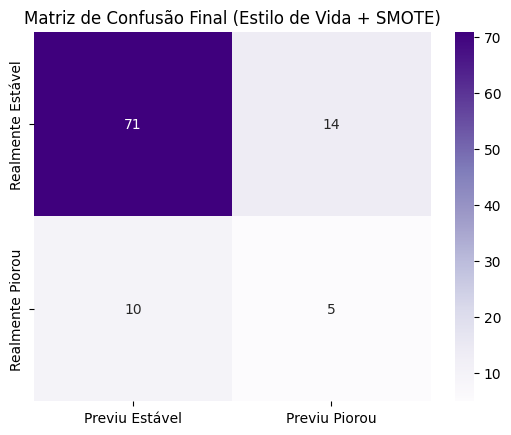

In [9]:
from imblearn.over_sampling import SMOTE
# Aplicando o SMOTE no conjunto de treino
smote = SMOTE(random_state=42)
x_treino_balanceado, y_treino_balanceado = smote.fit_resample(x_treino, y_treino)
print(" DEPOIS DO SMOTE (Dados de Estudo Balanceados)")
print(y_treino_balanceado.value_counts())
# Treinando o modelo novamente com os dados balanceados
modelo_rf_final = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf_final.fit(x_treino_balanceado, y_treino_balanceado)
# Fazendo previsões com o modelo treinado nos dados balanceados
previsoes_final = modelo_rf_final.predict(x_teste)
# Avaliando o modelo final
print(" BOLETIM FINAL DA IA (ESTILO DE VIDA + SMOTE):")
print(classification_report(y_teste, previsoes_final, target_names=['Estável (0)', 'Piorou (1)']))
# Fazendo a matriz de confusão do modelo final
matriz_final = confusion_matrix(y_teste, previsoes_final)
sns.heatmap(matriz_final, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Previu Estável', 'Previu Piorou'], 
            yticklabels=['Realmente Estável', 'Realmente Piorou'])
plt.title('Matriz de Confusão Final (Estilo de Vida + SMOTE)', fontsize=12)
plt.show()


## Conclusão

# 🏆 Conclusão do Capítulo 2: O Poder do Estilo de Vida e do Balanceamento

Neste segundo capítulo, mudei a minha abordagem. Em vez de focar apenas em exames clínicos, investiguei **Fatores de Estilo de Vida e Ambientais** (dados simulados com base em literatura médica) para prever a progressão da Esclerose Múltipla. 

Os resultados confirmaram a minha hipótese inicial e demonstraram a evolução real do meu modelo de Machine Learning:

### 1. A Descoberta dos Gatilhos (Mapa de Calor)
A análise de correlação provou que a doença não progride aleatoriamente. O algoritmo identificou com precisão os maiores vilões e heróis:
* **Gatilhos de Piora (Correlação Positiva):** Tabagismo (`0.32`), presença de Outras Doenças Autoimunes (`0.18`) e Alto Estresse (`0.16`).
* **Fatores Protetores (Correlação Negativa):** Boa Qualidade de Sono (`-0.08`), Níveis adequados de Vitamina D (`-0.08`) e Exercício Físico (`-0.07`).

### 2. A Evolução da Inteligência Artificial (O Foco no Recall)
A minha jornada para detectar os pacientes graves (aqueles que realmente iam piorar) teve três fases cruciais:
* **Fase 1 (Apenas Dados Clínicos - Cap. 1):** O modelo foi "preguiçoso". Recall de **0.00** (Não detectou ninguém).
* **Fase 2 (Dados de Estilo de Vida - Desbalanceado):** A qualidade dos dados ajudou a IA a acordar. Recall de **0.20** (Detectou 3 de 15 pacientes graves).
* **Fase 3 (Estilo de Vida + SMOTE):** Apliquei sobreamostragem para a IA focar na minoria grave. O Recall subiu para **0.33** (Detectou 5 de 15 pacientes).

### 3. O "Trade-off" Médico: Por que errar para mais é bom?
Ao aplicar o SMOTE na Fase 3, a IA aumentou os **Falsos Positivos** (classificou 14 pacientes estáveis como casos de risco). Em negócios tradicionais, isso poderia ser visto como um problema, mas na **Saúde (HealthTech)**, este é o cenário ideal. 

Aumentei a sensibilidade do algoritmo porque, em doenças neurológicas, o custo de um **Falso Negativo** (mandar um paciente grave para casa sem tratamento) é infinitamente pior do que um **Falso Positivo** (pedir exames preventivos extras para um paciente estável).

### 🧠 Conclusão Geral do Projeto
A Esclerose Múltipla é uma doença multifatorial. Este projeto prova matematicamente que a união entre **Dados Clínicos de Rotina** e **Monitoramento Contínuo de Estilo de Vida** é o futuro da medicina preditiva. Modelos de Machine Learning, quando devidamente balanceados e focados nas métricas corretas (Recall em vez de Acurácia), podem atuar como radares eficientes para médicos intervirem antes que o surto neurológico aconteça.